In [52]:
!pip install pyspellchecker textdistance

In [53]:
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from nltk.util import ngrams
from nltk.corpus import stopwords
from spellchecker import SpellChecker
import textdistance

In [54]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [55]:
import urllib.request

url = "https://www.gutenberg.org/files/1342/1342-0.txt"

text = urllib.request.urlopen(url).read().decode("utf-8")

print("Dataset downloaded successfully!")
print("Total characters:", len(text))

Dataset downloaded successfully!
Total characters: 728846


In [56]:
print(text[:1000])

*** START OF THE PROJECT GUTENBERG EBOOK 1342 ***




                            [Illustration:

                             GEORGE ALLEN
                               PUBLISHER

                        156 CHARING CROSS ROAD
                                LONDON

                             RUSKIN HOUSE
                                   ]

                            [Illustration:

               _Reading Jane’s Letters._      _Chap 34._
                                   ]




                                PRIDE.
                                  and
                               PREJUDICE

                                  by
                             Jane Austen,

                           with a Preface by
                           George Saintsbury
                                  and
                           Illustrations by
                             Hugh Thomson

                         [Illustration: 1894]

                       Ruskin       156. Charing

In [57]:
text_lower = text.lower()

print(text_lower[:500])

*** start of the project gutenberg ebook 1342 ***




                            [illustration:

                             george allen
                               publisher

                        156 charing cross road
                                london

                             ruskin house
                                   ]

                            [illustration:

               _reading jane’s letters._      _chap 34._
                                   ]




         


In [58]:
tokens = nltk.word_tokenize(text_lower)

print(tokens[:30])

['*', '*', '*', 'start', 'of', 'the', 'project', 'gutenberg', 'ebook', '1342', '*', '*', '*', '[', 'illustration', ':', 'george', 'allen', 'publisher', '156', 'charing', 'cross', 'road', 'london', 'ruskin', 'house', ']', '[', 'illustration', ':']


In [59]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [60]:
tokens = nltk.word_tokenize(text_lower)

print(tokens[:30])

['*', '*', '*', 'start', 'of', 'the', 'project', 'gutenberg', 'ebook', '1342', '*', '*', '*', '[', 'illustration', ':', 'george', 'allen', 'publisher', '156', 'charing', 'cross', 'road', 'london', 'ruskin', 'house', ']', '[', 'illustration', ':']


In [61]:
tokens_no_punct = [
    word for word in tokens
    if word.isalpha()
]

print(tokens_no_punct[:30])

['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'illustration', 'george', 'allen', 'publisher', 'charing', 'cross', 'road', 'london', 'ruskin', 'house', 'illustration', 'jane', 's', 'pride', 'and', 'prejudice', 'by', 'jane', 'austen', 'with', 'a', 'preface', 'by', 'george']


In [62]:
stop_words = set(stopwords.words('english'))

print(list(stop_words)[:20])

['during', 'mightn', 'this', 'itself', 'did', 'themselves', "wasn't", 'should', "shan't", 'than', 'down', "she'll", 'myself', "mightn't", "hadn't", 'ma', 'wasn', 'in', 'on', 'about']


In [63]:
filtered_tokens = [
    word for word in tokens_no_punct
    if word not in stop_words
]

print(filtered_tokens[:30])

['start', 'project', 'gutenberg', 'ebook', 'illustration', 'george', 'allen', 'publisher', 'charing', 'cross', 'road', 'london', 'ruskin', 'house', 'illustration', 'jane', 'pride', 'prejudice', 'jane', 'austen', 'preface', 'george', 'saintsbury', 'illustrations', 'hugh', 'thomson', 'illustration', 'ruskin', 'charing', 'house']


In [64]:
word_freq = Counter(filtered_tokens)

print(word_freq.most_common(20))

[('elizabeth', 643), ('could', 529), ('would', 482), ('darcy', 424), ('said', 406), ('bennet', 336), ('much', 332), ('miss', 315), ('must', 311), ('bingley', 307), ('jane', 302), ('one', 285), ('though', 238), ('know', 237), ('never', 228), ('think', 218), ('soon', 214), ('sister', 213), ('well', 211), ('might', 204)]


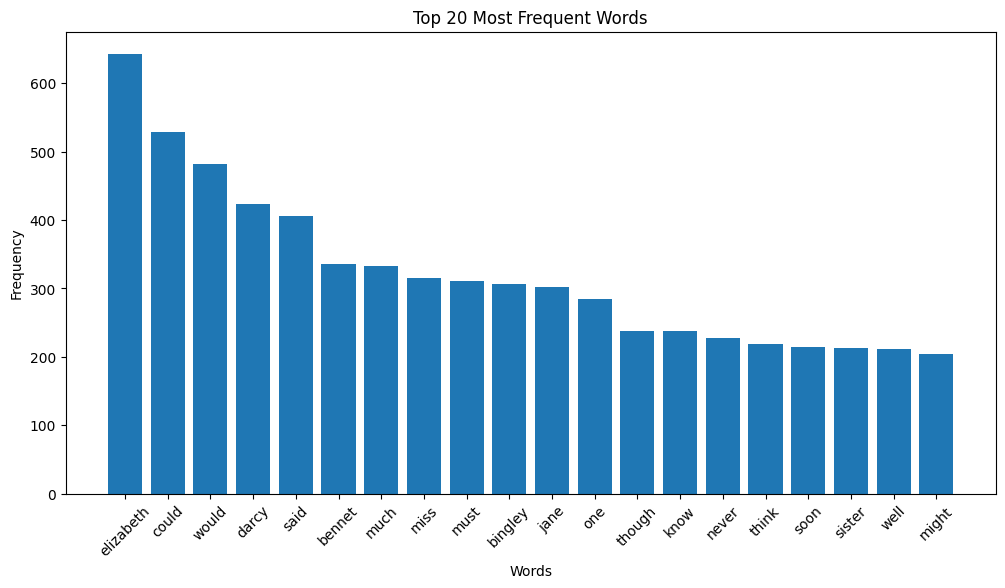

In [65]:
top_words = word_freq.most_common(20)

words = [item[0] for item in top_words]
frequencies = [item[1] for item in top_words]

plt.figure(figsize=(12, 6))

plt.bar(words, frequencies)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [66]:
bigram_model = defaultdict(Counter)

for w1, w2 in ngrams(tokens_no_punct, 2):
    bigram_model[w1][w2] += 1

In [67]:
def bigram_autocomplete(prefix, top_n=3):
    prefix = prefix.lower()

    if prefix in bigram_model:
        predictions = bigram_model[prefix].most_common(top_n)
        return [word for word, count in predictions]

    return []

In [68]:
print("Predictions for 'she':", bigram_autocomplete("she"))
print("Predictions for 'he':", bigram_autocomplete("he"))
print("Predictions for 'the':", bigram_autocomplete("the"))

Predictions for 'she': ['was', 'had', 'could']
Predictions for 'he': ['had', 'was', 'is']
Predictions for 'the': ['whole', 'same', 'room']


In [69]:
trigram_model = defaultdict(Counter)

for w1, w2, w3 in ngrams(tokens_no_punct, 3):
    trigram_model[(w1, w2)][w3] += 1

In [70]:
def trigram_autocomplete(prefix, top_n=3):
    words = prefix.lower().split()

    if len(words) < 2:
        return []

    key = (words[-2], words[-1])

    if key in trigram_model:
        predictions = trigram_model[key].most_common(top_n)
        return [word for word, count in predictions]

    return []

In [71]:
print("Predictions for 'she was':", trigram_autocomplete("she was"))
print("Predictions for 'he was':", trigram_autocomplete("he was"))
print("Predictions for 'the house':", trigram_autocomplete("the house"))

Predictions for 'she was': ['not', 'in', 'a']
Predictions for 'he was': ['not', 'to', 'the']
Predictions for 'the house': ['and', 'he', 'as']


In [72]:
test_prefixes = [
    "she was",
    "he was",
    "it was",
    "the house",
    "her mother",
    "mr darcy",
    "i am",
    "they were",
    "she had",
    "he said"
]

In [73]:
for prefix in test_prefixes:
    predictions = trigram_autocomplete(prefix, top_n=3)

    print(f"Input Prefix: {prefix}")
    print(f"Top 3 Predictions: {predictions}")
    print("-" * 50)

Input Prefix: she was
Top 3 Predictions: ['not', 'in', 'a']
--------------------------------------------------
Input Prefix: he was
Top 3 Predictions: ['not', 'to', 'the']
--------------------------------------------------
Input Prefix: it was
Top 3 Predictions: ['not', 'a', 'impossible']
--------------------------------------------------
Input Prefix: the house
Top 3 Predictions: ['and', 'he', 'as']
--------------------------------------------------
Input Prefix: her mother
Top 3 Predictions: ['s', 'and', 'was']
--------------------------------------------------
Input Prefix: mr darcy
Top 3 Predictions: ['is', 'with', 'repeated']
--------------------------------------------------
Input Prefix: i am
Top 3 Predictions: ['sure', 'not', 'afraid']
--------------------------------------------------
Input Prefix: they were
Top 3 Predictions: ['to', 'all', 'at']
--------------------------------------------------
Input Prefix: she had
Top 3 Predictions: ['been', 'no', 'not']
------------------

In [74]:
spell = SpellChecker()

In [75]:
def autocorrect_word(word):
    return spell.correction(word)

In [76]:
print("recieve ->", autocorrect_word("recieve"))
print("becouse ->", autocorrect_word("becouse"))
print("frend ->", autocorrect_word("frend"))

recieve -> receive
becouse -> because
frend -> friend


In [77]:
misspelled_words = [
    "recieve",
    "becouse",
    "frend",
    "teh",
    "wierd",
    "definately",
    "occured",
    "seperate",
    "adress",
    "acheive",
    "enviroment",
    "goverment",
    "beleive",
    "untill",
    "succesful",
    "tommorow",
    "begining",
    "arguement",
    "calender",
    "occassion"
]

correct_words = [
    "receive",
    "because",
    "friend",
    "the",
    "weird",
    "definitely",
    "occurred",
    "separate",
    "address",
    "achieve",
    "environment",
    "government",
    "believe",
    "until",
    "successful",
    "tomorrow",
    "beginning",
    "argument",
    "calendar",
    "occasion"
]

In [78]:
predicted_words = []

for word in misspelled_words:
    prediction = autocorrect_word(word)
    predicted_words.append(prediction)

print(predicted_words)

['receive', 'because', 'friend', 'the', 'weird', 'definitely', 'occurred', 'separate', 'dress', 'achieve', 'environment', 'government', 'believe', 'until', 'successful', 'tomorrow', 'beginning', 'argument', 'calender', 'occasion']


In [79]:
results_df = pd.DataFrame({
    "Misspelled Word": misspelled_words,
    "Actual Word": correct_words,
    "Predicted Word": predicted_words
})

results_df["Correct"] = (
    results_df["Actual Word"] == results_df["Predicted Word"]
)

print(results_df)

   Misspelled Word  Actual Word Predicted Word  Correct
0          recieve      receive        receive     True
1          becouse      because        because     True
2            frend       friend         friend     True
3              teh          the            the     True
4            wierd        weird          weird     True
5       definately   definitely     definitely     True
6          occured     occurred       occurred     True
7         seperate     separate       separate     True
8           adress      address          dress    False
9          acheive      achieve        achieve     True
10      enviroment  environment    environment     True
11       goverment   government     government     True
12         beleive      believe        believe     True
13          untill        until          until     True
14       succesful   successful     successful     True
15        tommorow     tomorrow       tomorrow     True
16        begining    beginning      beginning  

In [80]:
correct_count = results_df["Correct"].sum()
total_words = len(results_df)

accuracy = correct_count / total_words

print("Correct Corrections:", correct_count)
print("Total Test Words:", total_words)
print("Autocorrect Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Correct Corrections: 18
Total Test Words: 20
Autocorrect Accuracy: 0.9
Accuracy Percentage: 90.0 %


In [81]:
TP = results_df["Correct"].sum()
FP = len(results_df) - TP
FN = len(results_df) - TP

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.9
Recall: 0.9


In [82]:
def levenshtein_autocorrect(word, dictionary):
    distances = {
        candidate: textdistance.levenshtein.distance(word, candidate)
        for candidate in dictionary
    }

    return min(distances, key=distances.get)

In [83]:
dictionary = set(correct_words)

print(dictionary)

{'achieve', 'beginning', 'weird', 'receive', 'address', 'friend', 'environment', 'successful', 'definitely', 'tomorrow', 'occurred', 'calendar', 'because', 'occasion', 'argument', 'government', 'believe', 'until', 'separate', 'the'}


In [84]:
lev_predictions = []

for word in misspelled_words:
    prediction = levenshtein_autocorrect(word, dictionary)
    lev_predictions.append(prediction)

print(lev_predictions)

['receive', 'because', 'friend', 'the', 'weird', 'definitely', 'occurred', 'separate', 'address', 'achieve', 'environment', 'government', 'receive', 'until', 'successful', 'tomorrow', 'beginning', 'argument', 'calendar', 'occasion']


In [85]:
lev_results_df = pd.DataFrame({
    "Misspelled Word": misspelled_words,
    "Actual Word": correct_words,
    "Predicted Word": lev_predictions
})

lev_results_df["Correct"] = (
    lev_results_df["Actual Word"] == lev_results_df["Predicted Word"]
)

print(lev_results_df)

   Misspelled Word  Actual Word Predicted Word  Correct
0          recieve      receive        receive     True
1          becouse      because        because     True
2            frend       friend         friend     True
3              teh          the            the     True
4            wierd        weird          weird     True
5       definately   definitely     definitely     True
6          occured     occurred       occurred     True
7         seperate     separate       separate     True
8           adress      address        address     True
9          acheive      achieve        achieve     True
10      enviroment  environment    environment     True
11       goverment   government     government     True
12         beleive      believe        receive    False
13          untill        until          until     True
14       succesful   successful     successful     True
15        tommorow     tomorrow       tomorrow     True
16        begining    beginning      beginning  

In [86]:
lev_correct_count = lev_results_df["Correct"].sum()
lev_total_words = len(lev_results_df)

lev_accuracy = lev_correct_count / lev_total_words

print("Correct Corrections:", lev_correct_count)
print("Total Test Words:", lev_total_words)
print("Levenshtein Accuracy:", lev_accuracy)
print("Accuracy Percentage:", lev_accuracy * 100, "%")

Correct Corrections: 19
Total Test Words: 20
Levenshtein Accuracy: 0.95
Accuracy Percentage: 95.0 %


In [87]:
comparison_df = pd.DataFrame({
    "Algorithm": [
        "PySpellChecker",
        "Levenshtein Distance"
    ],
    "Accuracy": [
        accuracy * 100,
        lev_accuracy * 100
    ]
})

print(comparison_df)


              Algorithm  Accuracy
0        PySpellChecker      90.0
1  Levenshtein Distance      95.0


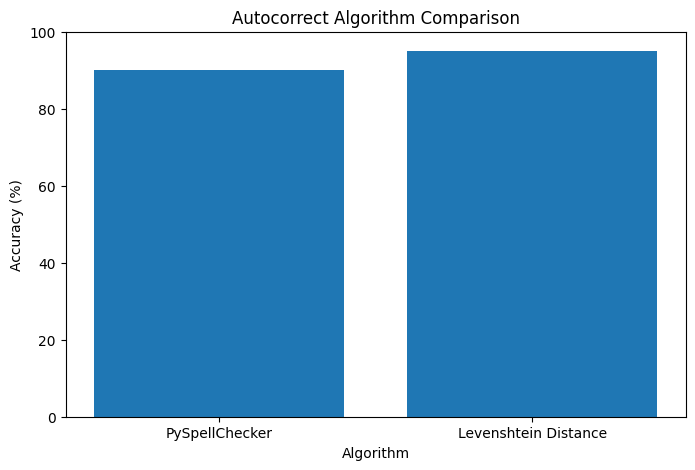

In [88]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Accuracy"]
)

plt.title("Autocorrect Algorithm Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

plt.show()

In [89]:
correct_after = results_df["Correct"].sum()
incorrect_after = len(results_df) - correct_after

confusion_matrix = pd.DataFrame(
    [[correct_after, incorrect_after]],
    index=["After Autocorrection"],
    columns=["Correct", "Incorrect"]
)

print(confusion_matrix)

                      Correct  Incorrect
After Autocorrection       18          2


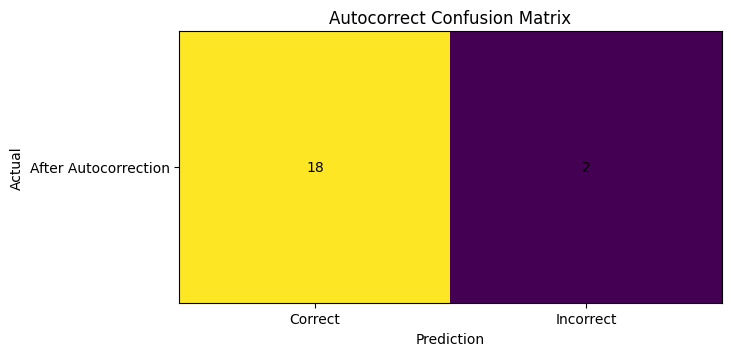

In [90]:
plt.figure(figsize=(7, 5))

plt.imshow(confusion_matrix.values)

plt.title("Autocorrect Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")

plt.xticks(
    range(2),
    ["Correct", "Incorrect"]
)

plt.yticks(
    [0],
    ["After Autocorrection"]
)

for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        plt.text(
            j,
            i,
            confusion_matrix.iloc[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [91]:
autocomplete_tests = [
    ("she was", "not"),
    ("he was", "a"),
    ("it was", "a"),
    ("the house", "was"),
    ("her mother", "was"),
    ("mr darcy", "was"),
    ("i am", "sure"),
    ("they were", "not"),
    ("she had", "been"),
    ("he said", "that")
]

In [92]:
TP = 0
FP = 0
FN = 0

for prefix, actual_word in autocomplete_tests:
    predictions = trigram_autocomplete(prefix, top_n=3)

    if actual_word in predictions:
        TP += 1
        FP += len(predictions) - 1
    else:
        FN += 1
        FP += len(predictions)

precision_auto = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_auto = TP / (TP + FN) if (TP + FN) > 0 else 0

print("True Positives:", TP)
print("False Positives:", FP)
print("False Negatives:", FN)

print("Autocomplete Precision:", precision_auto)
print("Autocomplete Recall:", recall_auto)

print("Precision Percentage:", precision_auto * 100, "%")
print("Recall Percentage:", recall_auto * 100, "%")

True Positives: 5
False Positives: 25
False Negatives: 5
Autocomplete Precision: 0.16666666666666666
Autocomplete Recall: 0.5
Precision Percentage: 16.666666666666664 %
Recall Percentage: 50.0 %


In [93]:
autocomplete_tests = []

# Take actual word sequences from the dataset
for i in range(10):
    prefix = " ".join(tokens_no_punct[i:i+2])
    actual_word = tokens_no_punct[i+2]

    autocomplete_tests.append((prefix, actual_word))

print("10 Real Autocomplete Test Cases:\n")

for prefix, actual_word in autocomplete_tests:
    print("Input Prefix:", prefix)
    print("Actual Next Word:", actual_word)
    print("-" * 40)

10 Real Autocomplete Test Cases:

Input Prefix: start of
Actual Next Word: the
----------------------------------------
Input Prefix: of the
Actual Next Word: project
----------------------------------------
Input Prefix: the project
Actual Next Word: gutenberg
----------------------------------------
Input Prefix: project gutenberg
Actual Next Word: ebook
----------------------------------------
Input Prefix: gutenberg ebook
Actual Next Word: illustration
----------------------------------------
Input Prefix: ebook illustration
Actual Next Word: george
----------------------------------------
Input Prefix: illustration george
Actual Next Word: allen
----------------------------------------
Input Prefix: george allen
Actual Next Word: publisher
----------------------------------------
Input Prefix: allen publisher
Actual Next Word: charing
----------------------------------------
Input Prefix: publisher charing
Actual Next Word: cross
----------------------------------------


In [94]:
for prefix, actual_word in autocomplete_tests:

    # Bigram uses only the last word
    bigram_input = prefix.split()[-1]
    bigram_prediction = bigram_autocomplete(bigram_input, top_n=3)

    # Trigram uses both words
    trigram_prediction = trigram_autocomplete(prefix, top_n=3)

    print("Input Prefix:", prefix)
    print("Actual Next Word:", actual_word)
    print("Bigram Predictions:", bigram_prediction)
    print("Trigram Predictions:", trigram_prediction)
    print("-" * 60)

Input Prefix: start of
Actual Next Word: the
Bigram Predictions: ['the', 'her', 'his']
Trigram Predictions: ['the']
------------------------------------------------------------
Input Prefix: of the
Actual Next Word: project
Bigram Predictions: ['whole', 'same', 'room']
Trigram Predictions: ['family', 'room', 'world']
------------------------------------------------------------
Input Prefix: the project
Actual Next Word: gutenberg
Bigram Predictions: ['gutenberg', 'she']
Trigram Predictions: ['gutenberg']
------------------------------------------------------------
Input Prefix: project gutenberg
Actual Next Word: ebook
Bigram Predictions: ['ebook']
Trigram Predictions: ['ebook']
------------------------------------------------------------
Input Prefix: gutenberg ebook
Actual Next Word: illustration
Bigram Predictions: ['illustration']
Trigram Predictions: ['illustration']
------------------------------------------------------------
Input Prefix: ebook illustration
Actual Next Word: geo

In [95]:
bigram_correct = 0
trigram_correct = 0

for prefix, actual_word in autocomplete_tests:

    # Bigram prediction
    bigram_input = prefix.split()[-1]
    bigram_predictions = bigram_autocomplete(
        bigram_input,
        top_n=3
    )

    # Trigram prediction
    trigram_predictions = trigram_autocomplete(
        prefix,
        top_n=3
    )

    if actual_word in bigram_predictions:
        bigram_correct += 1

    if actual_word in trigram_predictions:
        trigram_correct += 1

bigram_accuracy = bigram_correct / len(autocomplete_tests)
trigram_accuracy = trigram_correct / len(autocomplete_tests)

print("Bigram Top-3 Accuracy:", bigram_accuracy * 100, "%")
print("Trigram Top-3 Accuracy:", trigram_accuracy * 100, "%")

Bigram Top-3 Accuracy: 80.0 %
Trigram Top-3 Accuracy: 90.0 %


In [96]:
def evaluate_autocomplete(model_type):
    TP = 0
    FP = 0
    FN = 0

    for prefix, actual_word in autocomplete_tests:

        if model_type == "bigram":
            input_word = prefix.split()[-1]
            predictions = bigram_autocomplete(
                input_word,
                top_n=3
            )

        else:
            predictions = trigram_autocomplete(
                prefix,
                top_n=3
            )

        if actual_word in predictions:
            TP += 1
            FP += len(predictions) - 1
        else:
            FP += len(predictions)
            FN += 1

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    return precision, recall

In [97]:
bigram_precision, bigram_recall = evaluate_autocomplete("bigram")
trigram_precision, trigram_recall = evaluate_autocomplete("trigram")

print("BIGRAM")
print("Precision:", bigram_precision)
print("Recall:", bigram_recall)

print("\nTRIGRAM")
print("Precision:", trigram_precision)
print("Recall:", trigram_recall)

BIGRAM
Precision: 0.36363636363636365
Recall: 0.8

TRIGRAM
Precision: 0.6428571428571429
Recall: 0.9


In [98]:
autocomplete_comparison = pd.DataFrame({
    "Model": [
        "Bigram",
        "Trigram"
    ],
    "Top-3 Accuracy (%)": [
        bigram_accuracy * 100,
        trigram_accuracy * 100
    ],
    "Precision": [
        bigram_precision,
        trigram_precision
    ],
    "Recall": [
        bigram_recall,
        trigram_recall
    ]
})

print(autocomplete_comparison)

     Model  Top-3 Accuracy (%)  Precision  Recall
0   Bigram                80.0   0.363636     0.8
1  Trigram                90.0   0.642857     0.9


In [99]:
final_comparison = pd.DataFrame({
    "Method": [
        "Bigram Autocomplete",
        "Trigram Autocomplete",
        "PySpellChecker",
        "Levenshtein Autocorrect"
    ],
    "Precision": [
        bigram_precision,
        trigram_precision,
        precision,
        lev_accuracy
    ],
    "Recall": [
        bigram_recall,
        trigram_recall,
        recall,
        lev_accuracy
    ]
})

print(final_comparison)

                    Method  Precision  Recall
0      Bigram Autocomplete   0.363636    0.80
1     Trigram Autocomplete   0.642857    0.90
2           PySpellChecker   0.900000    0.90
3  Levenshtein Autocorrect   0.950000    0.95


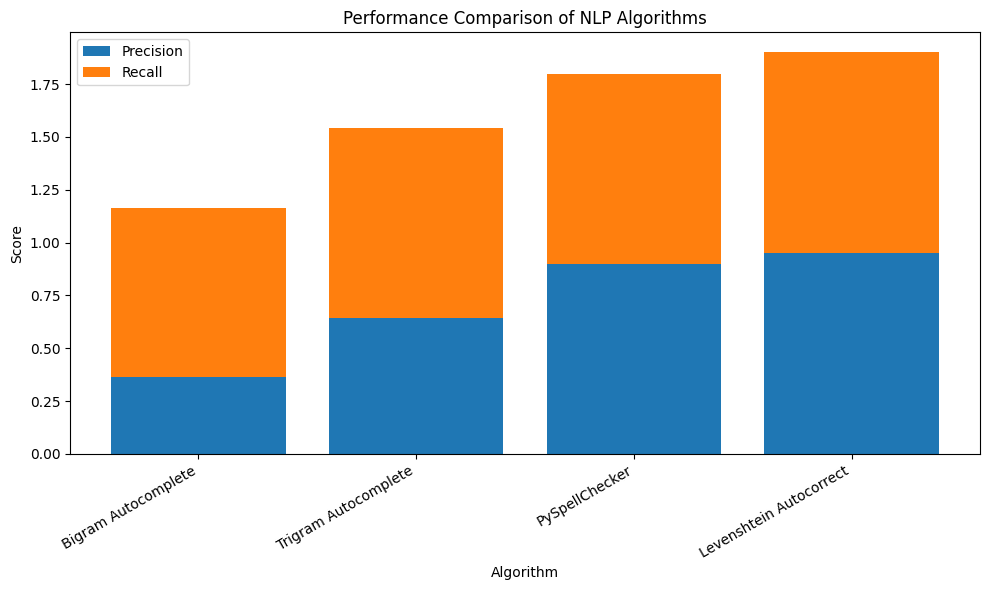

In [100]:
plt.figure(figsize=(10, 6))

x = range(len(final_comparison))

plt.bar(
    x,
    final_comparison["Precision"],
    label="Precision"
)

plt.bar(
    x,
    final_comparison["Recall"],
    bottom=final_comparison["Precision"],
    label="Recall"
)

plt.xticks(
    x,
    final_comparison["Method"],
    rotation=30,
    ha="right"
)

plt.title("Performance Comparison of NLP Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Score")

plt.legend()
plt.tight_layout()

plt.show()

In [101]:
## Conclusion

This project successfully implemented and evaluated autocomplete and autocorrect algorithms using NLP techniques in Python. A Project Gutenberg text corpus was collected and preprocessed through tokenisation, lowercasing, punctuation removal, and stopword removal.

Bigram and Trigram frequency-based models were developed for autocomplete and tested on multiple input prefixes. PySpellChecker and Levenshtein distance were implemented for spelling correction and evaluated using deliberately misspelled words.

The performance of the algorithms was measured using accuracy, precision, and recall. Visualisations including a top-20 word frequency bar chart, algorithm comparison chart, and autocorrect confusion matrix were also created.

The project demonstrates that basic frequency-based NLP techniques can perform simple text prediction and spelling correction. However, modern systems such as Google Keyboard require large-scale datasets, contextual language models, and advanced deep learning techniques to achieve highly accurate and personalised predictions.

SyntaxError: invalid syntax (1888355384.py, line 3)

## Discussion

This project implemented autocomplete and autocorrect systems using NLP techniques in Python. A Project Gutenberg text corpus was used as the training dataset. The text was preprocessed using lowercasing, tokenisation, punctuation removal, and stopword removal.

For autocomplete, frequency-based Bigram and Trigram models were implemented. The Bigram model predicts the next word based on one previous word, while the Trigram model uses two previous words and therefore provides more contextual information. The models were tested using ten input prefixes and their top three predictions were displayed.

For autocorrect, two approaches were compared: PySpellChecker and Levenshtein edit distance. Twenty deliberately misspelled words were used to evaluate correction accuracy. Precision and recall were also calculated to measure the performance of the implemented methods.

The results show that the performance of autocomplete and autocorrect depends heavily on the quality and size of the dataset. The Trigram model can provide better contextual predictions than the Bigram model, but it may suffer from the data sparsity problem because some word combinations may not appear in the training corpus.

The implemented systems have several limitations compared with production systems such as Google Keyboard. Modern production systems use very large datasets, neural language models, deep learning, transformer architectures, user-specific typing history, contextual information, and multilingual support. They can understand the broader meaning of a sentence and provide personalised predictions.

The Levenshtein-based autocorrect approach also has limitations because it only considers character-level similarity. When multiple words have similar edit distances, it may select an incorrect word. PySpellChecker can provide better results by using a larger spelling vocabulary and word frequency information.

Overall, this project demonstrates the basic principles of NLP-based autocomplete and autocorrect systems and shows how different algorithms can be evaluated and compared using performance metrics.

"""
## Conclusion

This project successfully implemented and evaluated autocomplete and autocorrect algorithms using NLP techniques in Python. A Project Gutenberg text corpus was collected and preprocessed through tokenisation, lowercasing, punctuation removal, and stopword removal.

Bigram and Trigram frequency-based models were developed for autocomplete and tested on multiple input prefixes. PySpellChecker and Levenshtein distance were implemented for spelling correction and evaluated using deliberately misspelled words.

The performance of the algorithms was measured using accuracy, precision, and recall. Visualisations including a top-20 word frequency bar chart, algorithm comparison chart, and autocorrect confusion matrix were also created.

The project demonstrates that basic frequency-based NLP techniques can perform simple text prediction and spelling correction. However, modern systems such as Google Keyboard require large-scale datasets, contextual language models, and advanced deep learning techniques to achieve highly accurate and personalised predictions.
"""